# Mini Project: Regression Algorithms Exploration
## Insurance Cost Prediction using Linear Regression and Polynomial Regression

**Dataset:** Medical Cost Personal Dataset  
**Prediction Task:** Predict insurance expenses based on personal and health-related features.

In this notebook, we explore the dataset, perform preprocessing, train regression models, evaluate their performance, and interpret the results.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
file_path = r"C:\Users\faisa\Downloads\insurance.csv"
df = pd.read_csv(file_path)

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (1338, 7)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

Duplicate rows: 1


## 1. Introduction

This dataset contains information about individuals, including their age, sex, BMI, number of children, smoking status, and region.

The objective of this project is to predict the medical insurance expenses using regression algorithms.

We will apply:
- Linear Regression
- Polynomial Regression

Then we will evaluate both models using:
- MAE
- MSE
- RMSE
- R² Score

## 2. Algorithm Explanation

### Linear Regression
Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value.

It assumes a linear relationship between the input features and the target variable.

The main equation is:

\[
y = wX + b
\]

Where:
- \( y \) = predicted value
- \( X \) = input features
- \( w \) = weights
- \( b \) = intercept

**When should it be used?**
- When the relationship between variables is approximately linear
- When we need a simple and interpretable model

**Advantages**
- Easy to understand
- Fast to train
- Interpretable

**Limitations**
- Cannot model complex nonlinear relationships well
- Sensitive to outliers

---

### Polynomial Regression
Polynomial Regression is an extension of Linear Regression.

It transforms the original features into polynomial features, allowing the model to capture nonlinear patterns.

Example:

\[
y = w_0 + w_1x + w_2x^2 + w_3x^3
\]

**When should it be used?**
- When the relationship between variables is nonlinear
- When a straight line is not enough to fit the data

**Advantages**
- Can model curved relationships
- More flexible than linear regression

**Limitations**
- Can overfit if the polynomial degree is too high
- Less interpretable than simple linear regression

In [5]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [6]:
X = df.drop("expenses", axis=1)
y = df["expenses"]

print("Features:")
print(X.columns.tolist())

print("\nTarget variable:")
print("expenses")

Features:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Target variable:
expenses


## 3. Exploratory Data Analysis (EDA)

In this section, we will:
- Explore the dataset structure
- Check missing values
- Check duplicates
- Visualize numerical distributions
- Analyze relationships between features and the target variable

In [7]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['age', 'bmi', 'children']
Categorical columns: ['sex', 'smoker', 'region']


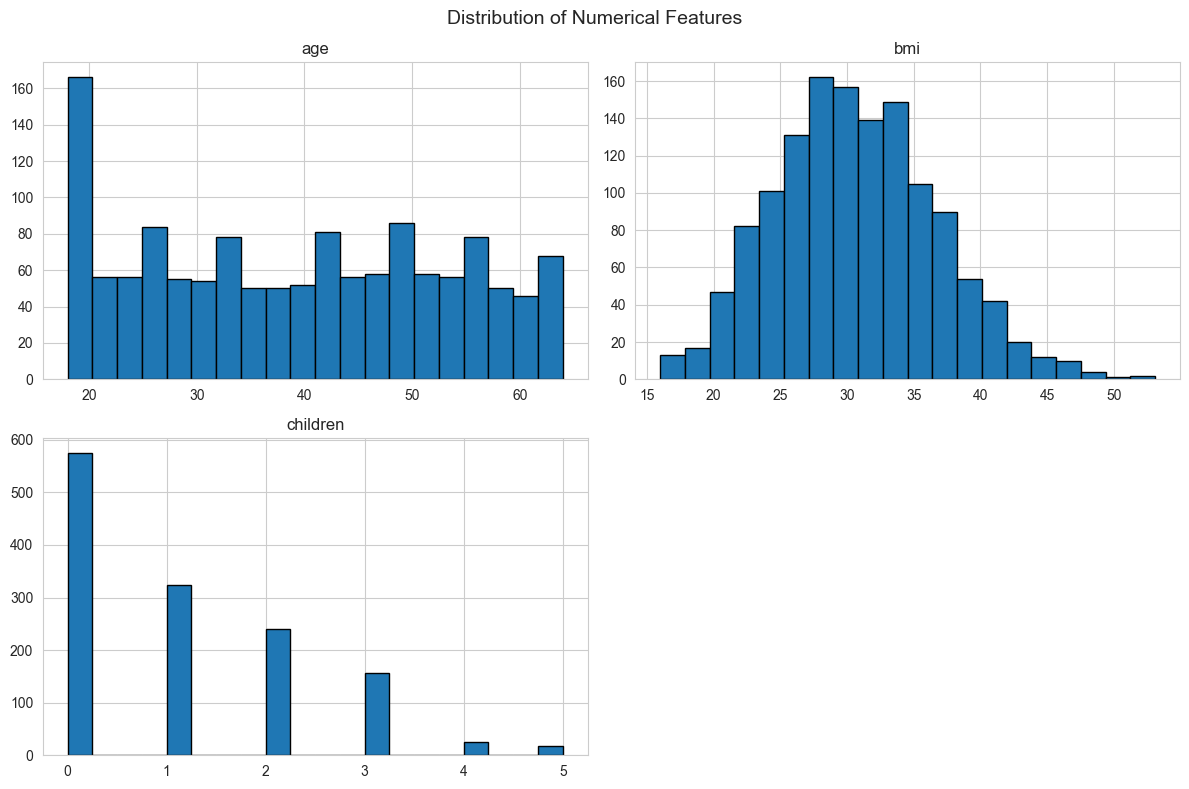

In [8]:
df[numerical_cols].hist(bins=20, figsize=(12, 8), edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

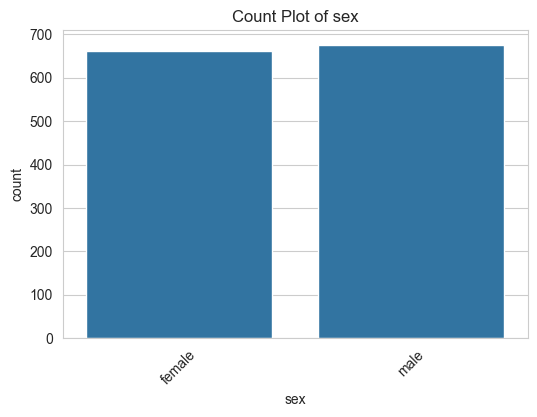

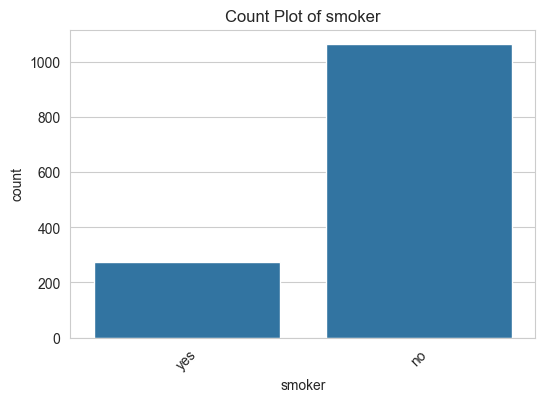

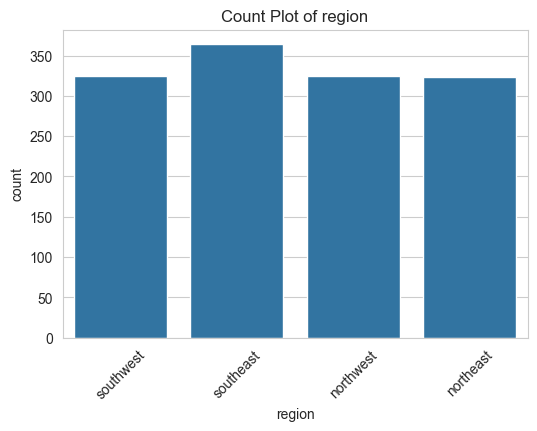

In [9]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

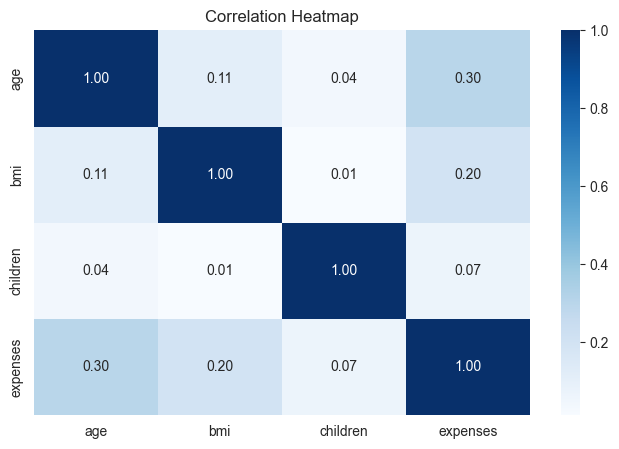

In [10]:
plt.figure(figsize=(8, 5))
corr = df[numerical_cols + ["expenses"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

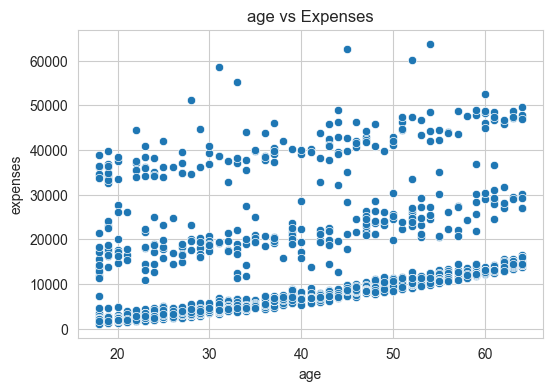

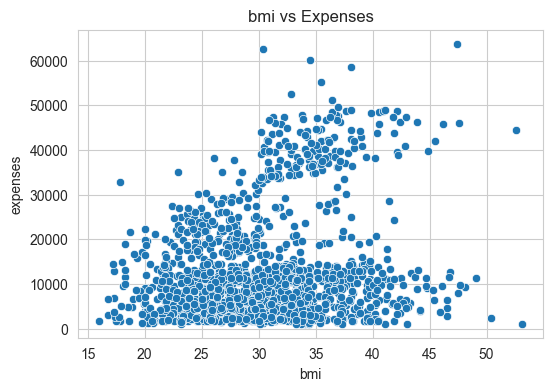

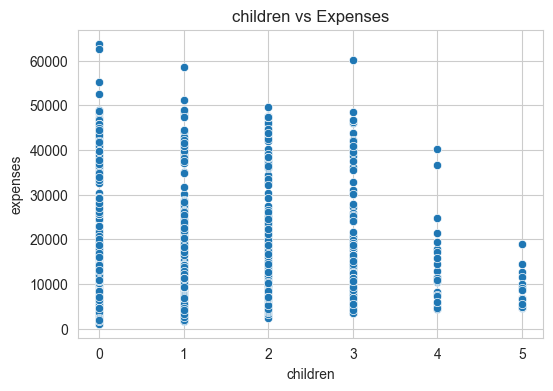

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="expenses")
    plt.title(f"{col} vs Expenses")
    plt.show()

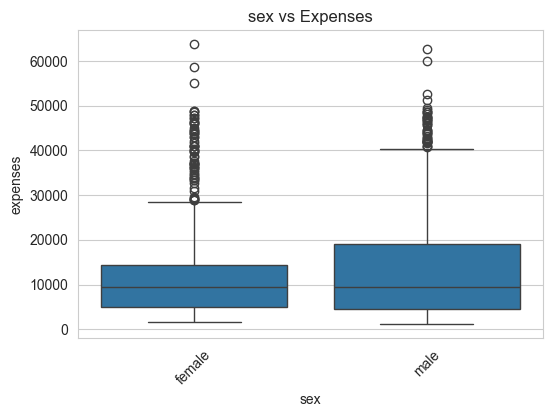

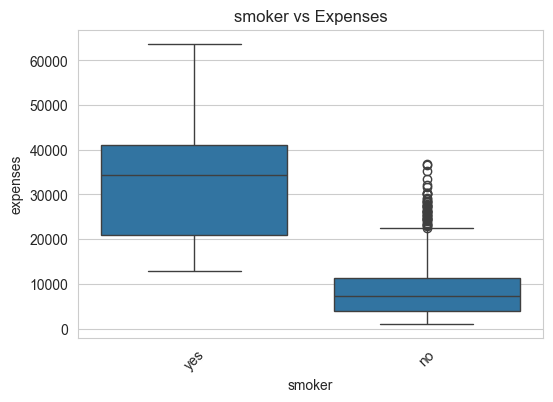

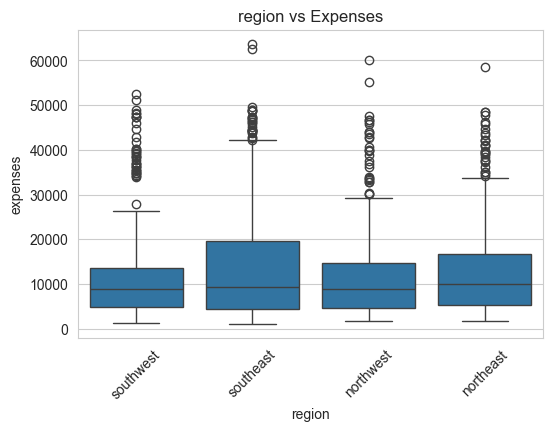

In [12]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, y="expenses")
    plt.title(f"{col} vs Expenses")
    plt.xticks(rotation=45)
    plt.show()

## 4. Key Insights from EDA

From the exploratory data analysis, several important observations were identified:

1. **Smoking status has the strongest impact on insurance expenses.**  
   The boxplot shows that smokers have significantly higher medical costs compared to non-smokers. This indicates that smoking is one of the most influential predictors of insurance charges.

2. **Age shows a moderate positive relationship with expenses.**  
   The scatter plot indicates that insurance costs generally increase as age increases. Older individuals tend to have higher medical expenses.

3. **BMI has a noticeable effect on insurance costs.**  
   Individuals with higher BMI values tend to have higher insurance expenses, although the relationship is not perfectly linear.

4. **The number of children has a weak relationship with expenses.**  
   The scatter plot suggests that having more children does not strongly affect insurance costs.

5. **Gender does not significantly affect insurance expenses.**  
   The boxplot for sex shows similar distributions of expenses for males and females.

6. **Insurance expenses are relatively similar across regions.**  
   The boxplot comparing regions shows no major differences in costs between geographic areas.

7. **The correlation heatmap confirms that age and BMI have the strongest relationships with expenses among numerical variables**, while the number of children has very little correlation with the target variable.

In [13]:
df = df.drop_duplicates()

print("New shape after removing duplicates:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

New shape after removing duplicates: (1337, 7)
Duplicate rows after cleaning: 0


In [14]:
X = df.drop("expenses", axis=1)
y = df["expenses"]

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

## 5. Data Preprocessing

In this step:
- Missing values do not need handling because the dataset contains none.
- The duplicate row is removed.
- Categorical features are encoded using One-Hot Encoding.
- Numerical features are scaled using StandardScaler.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1069, 6)
X_test shape: (268, 6)
y_train shape: (1069,)
y_test shape: (268,)


In [16]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

In [17]:
linear_model = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [18]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-" * 30)
print("MAE :", round(mae_linear, 2))
print("MSE :", round(mse_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R2  :", round(r2_linear, 4))

Linear Regression Results
------------------------------
MAE : 4177.27
MSE : 35481471.6
RMSE: 5956.63
R2  : 0.8069


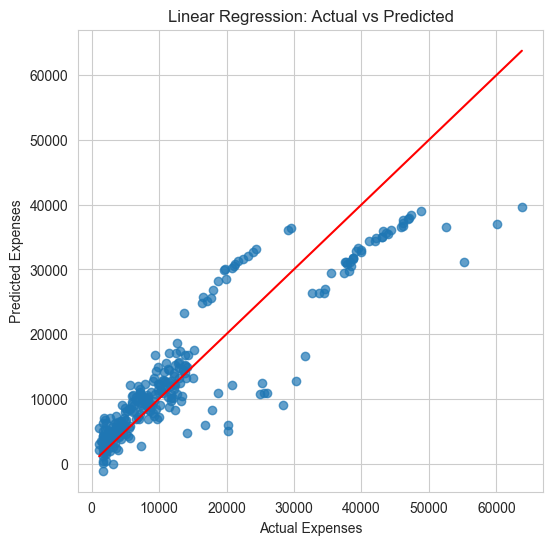

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

## 6. Polynomial Regression

Polynomial Regression extends Linear Regression by creating additional polynomial terms.

This helps the model capture nonlinear patterns in the data.

In this notebook, we use degree = 2.

In [20]:
poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

In [21]:
poly_model = Pipeline(steps=[
    ("preprocessor", poly_preprocessor),
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

In [22]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results")
print("-" * 30)
print("MAE :", round(mae_poly, 2))
print("MSE :", round(mse_poly, 2))
print("RMSE:", round(rmse_poly, 2))
print("R2  :", round(r2_poly, 4))

Polynomial Regression Results
------------------------------
MAE : 2869.81
MSE : 21581244.5
RMSE: 4645.56
R2  : 0.8826


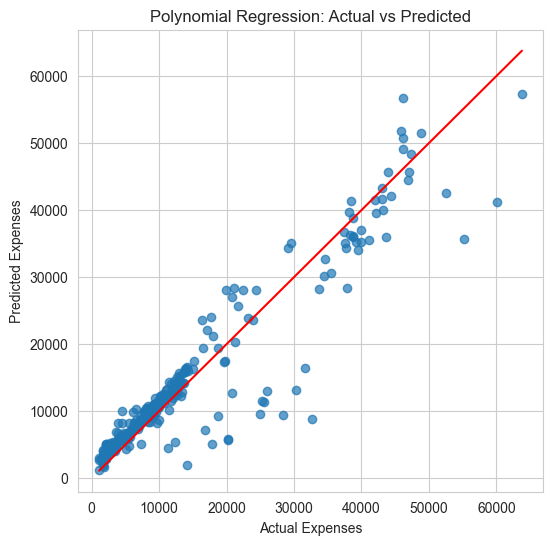

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()

In [24]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "MAE": [mae_linear, mae_poly],
    "MSE": [mse_linear, mse_poly],
    "RMSE": [rmse_linear, rmse_poly],
    "R2 Score": [r2_linear, r2_poly]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4177.267596,3.548147e+07,5956.632572,0.806910
1,Polynomial Regression,2869.810801,2.158124e+07,4645.561807,0.882555


In [25]:
best_model = results.sort_values(by="R2 Score", ascending=False).iloc[0]

print("Best model based on R2 Score:")
print(best_model)

Best model based on R2 Score:
Model       Polynomial Regression
MAE                   2869.810801
MSE               21581244.504887
RMSE                  4645.561807
R2 Score                 0.882555
Name: 1, dtype: object


## 7. Interpretation of Results

After training and evaluating both Linear Regression and Polynomial Regression models, we observed noticeable differences in their performance.

The Linear Regression model achieved an R² score of approximately **0.81**, which means the model explains about **81% of the variance in insurance expenses**. This indicates that the model captures a significant portion of the relationship between the features and the target variable. However, the scatter plot of Actual vs Predicted values shows that many points deviate from the ideal prediction line, especially for higher expense values. This suggests that a purely linear relationship may not fully represent the patterns in the dataset.

On the other hand, the Polynomial Regression model produced better results with an **R² score of 0.88**, along with lower MAE, MSE, and RMSE values. The scatter plot for Polynomial Regression shows that the predicted values align more closely with the diagonal reference line, indicating improved prediction accuracy.

This improvement occurs because Polynomial Regression can capture **non-linear relationships** between variables. In this dataset, certain features such as **age, BMI, and smoking status** influence insurance costs in a way that is not strictly linear. By adding polynomial features, the model becomes capable of modeling these more complex relationships.

Overall, the results indicate that **Polynomial Regression performs better for this dataset**, as it reduces prediction error and explains a larger portion of the variance in medical insurance expenses.

## 8. Conclusion

In this project, we explored regression techniques to predict medical insurance expenses using the Insurance Cost dataset. The analysis began with exploratory data analysis (EDA) to understand the dataset structure, visualize relationships between variables, and identify important predictors.

The results showed that certain features, especially smoking status, age, and BMI, have a strong influence on insurance charges. These factors significantly contribute to variations in medical costs.

Two regression models were implemented: Linear Regression and Polynomial Regression. After evaluating both models using MAE, MSE, RMSE, and R² Score, Polynomial Regression achieved better performance. The Polynomial model obtained an R² score of approximately **0.88**, compared to **0.81** for the Linear Regression model, indicating a better fit to the data.

The improvement occurs because Polynomial Regression can capture non-linear relationships that a simple linear model cannot fully represent.

Overall, this project demonstrates how regression models can be used to analyze real-world data and predict insurance costs. With further improvements such as feature engineering or hyperparameter tuning, the model performance could potentially be enhanced even more.

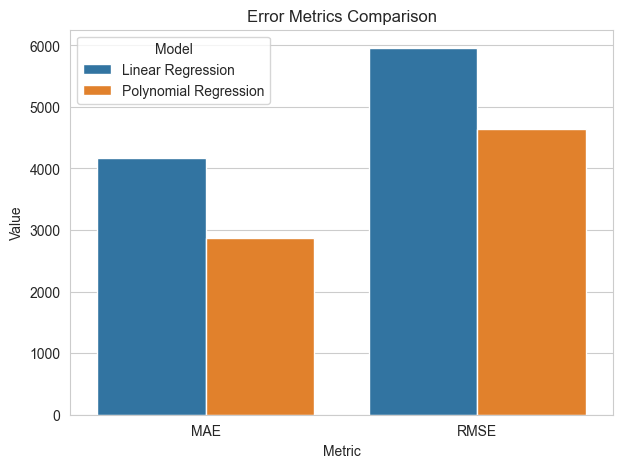

In [26]:
error_metrics = results[["Model", "MAE", "RMSE"]]

plt.figure(figsize=(7,5))
sns.barplot(data=error_metrics.melt(id_vars="Model"),
            x="variable", y="value", hue="Model")

plt.title("Error Metrics Comparison")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.show()

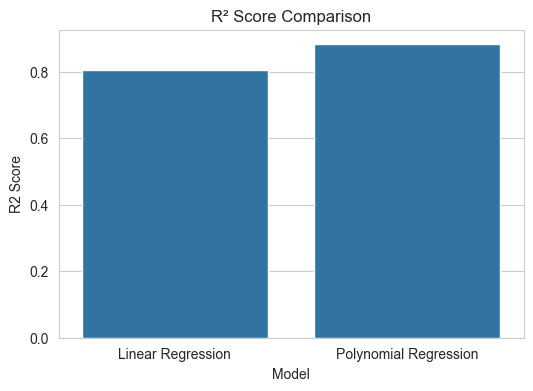

In [27]:
plt.figure(figsize=(6,4))
sns.barplot(data=results, x="Model", y="R2 Score")

plt.title("R² Score Comparison")
plt.show()